In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Blood_samples_dataset_balanced_2(f).csv")
df.head()
 

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse


In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(2351, 25)
Glucose                                      float64
Cholesterol                                  float64
Hemoglobin                                   float64
Platelets                                    float64
White Blood Cells                            float64
Red Blood Cells                              float64
Hematocrit                                   float64
Mean Corpuscular Volume                      float64
Mean Corpuscular Hemoglobin                  float64
Mean Corpuscular Hemoglobin Concentration    float64
Insulin                                      float64
BMI                                          float64
Systolic Blood Pressure                      float64
Diastolic Blood Pressure                     float64
Triglycerides                                float64
HbA1c                                        float64
LDL Cholesterol                              float64
HDL Cholesterol                              float64
ALT                                

In [4]:
print(df['Disease'].value_counts())

Disease
Anemia      623
Healthy     556
Diabetes    540
Thalasse    509
Thromboc    123
Name: count, dtype: int64


In [5]:

df.describe()

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,Triglycerides,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein
count,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,...,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000
mean,0.362828,0.393648,0.586190,0.504027,0.511086,0.506590,0.507152,0.492200,0.484459,0.562273,...,0.374373,0.439112,0.421777,0.546079,0.434972,0.452138,0.582255,0.425075,0.454597,0.430308
std,0.251889,0.239449,0.271498,0.303347,0.277270,0.266565,0.285537,0.275735,0.315618,0.273281,...,0.256981,0.263779,0.252124,0.269511,0.267388,0.242075,0.250915,0.229298,0.251189,0.243034
min,0.010994,0.012139,0.003021,0.012594,0.010139,0.044565,0.011772,0.046942,0.000554,0.006947,...,0.005217,0.016256,0.033037,0.039505,0.007186,0.013013,0.114550,0.021239,0.007490,0.004867
25%,0.129198,0.195818,0.346092,0.200865,0.259467,0.263589,0.288132,0.287532,0.207938,0.355774,...,0.184604,0.188750,0.217757,0.307132,0.211078,0.239659,0.339125,0.213026,0.288961,0.196192
50%,0.351722,0.397083,0.609836,0.533962,0.527381,0.467431,0.493428,0.453052,0.420723,0.603635,...,0.317857,0.466375,0.413071,0.512941,0.373235,0.486317,0.610860,0.417295,0.426863,0.481601
75%,0.582278,0.582178,0.791215,0.754841,0.743164,0.743670,0.753657,0.722293,0.778160,0.741381,...,0.572330,0.652514,0.604753,0.779378,0.710319,0.616181,0.800666,0.606719,0.682164,0.631426
max,0.968460,0.905026,0.983306,0.999393,0.990786,1.000000,0.977520,0.995263,0.963235,0.975586,...,0.973679,0.950218,0.983826,0.989411,0.942549,0.994460,0.996873,0.925924,0.972803,0.797906


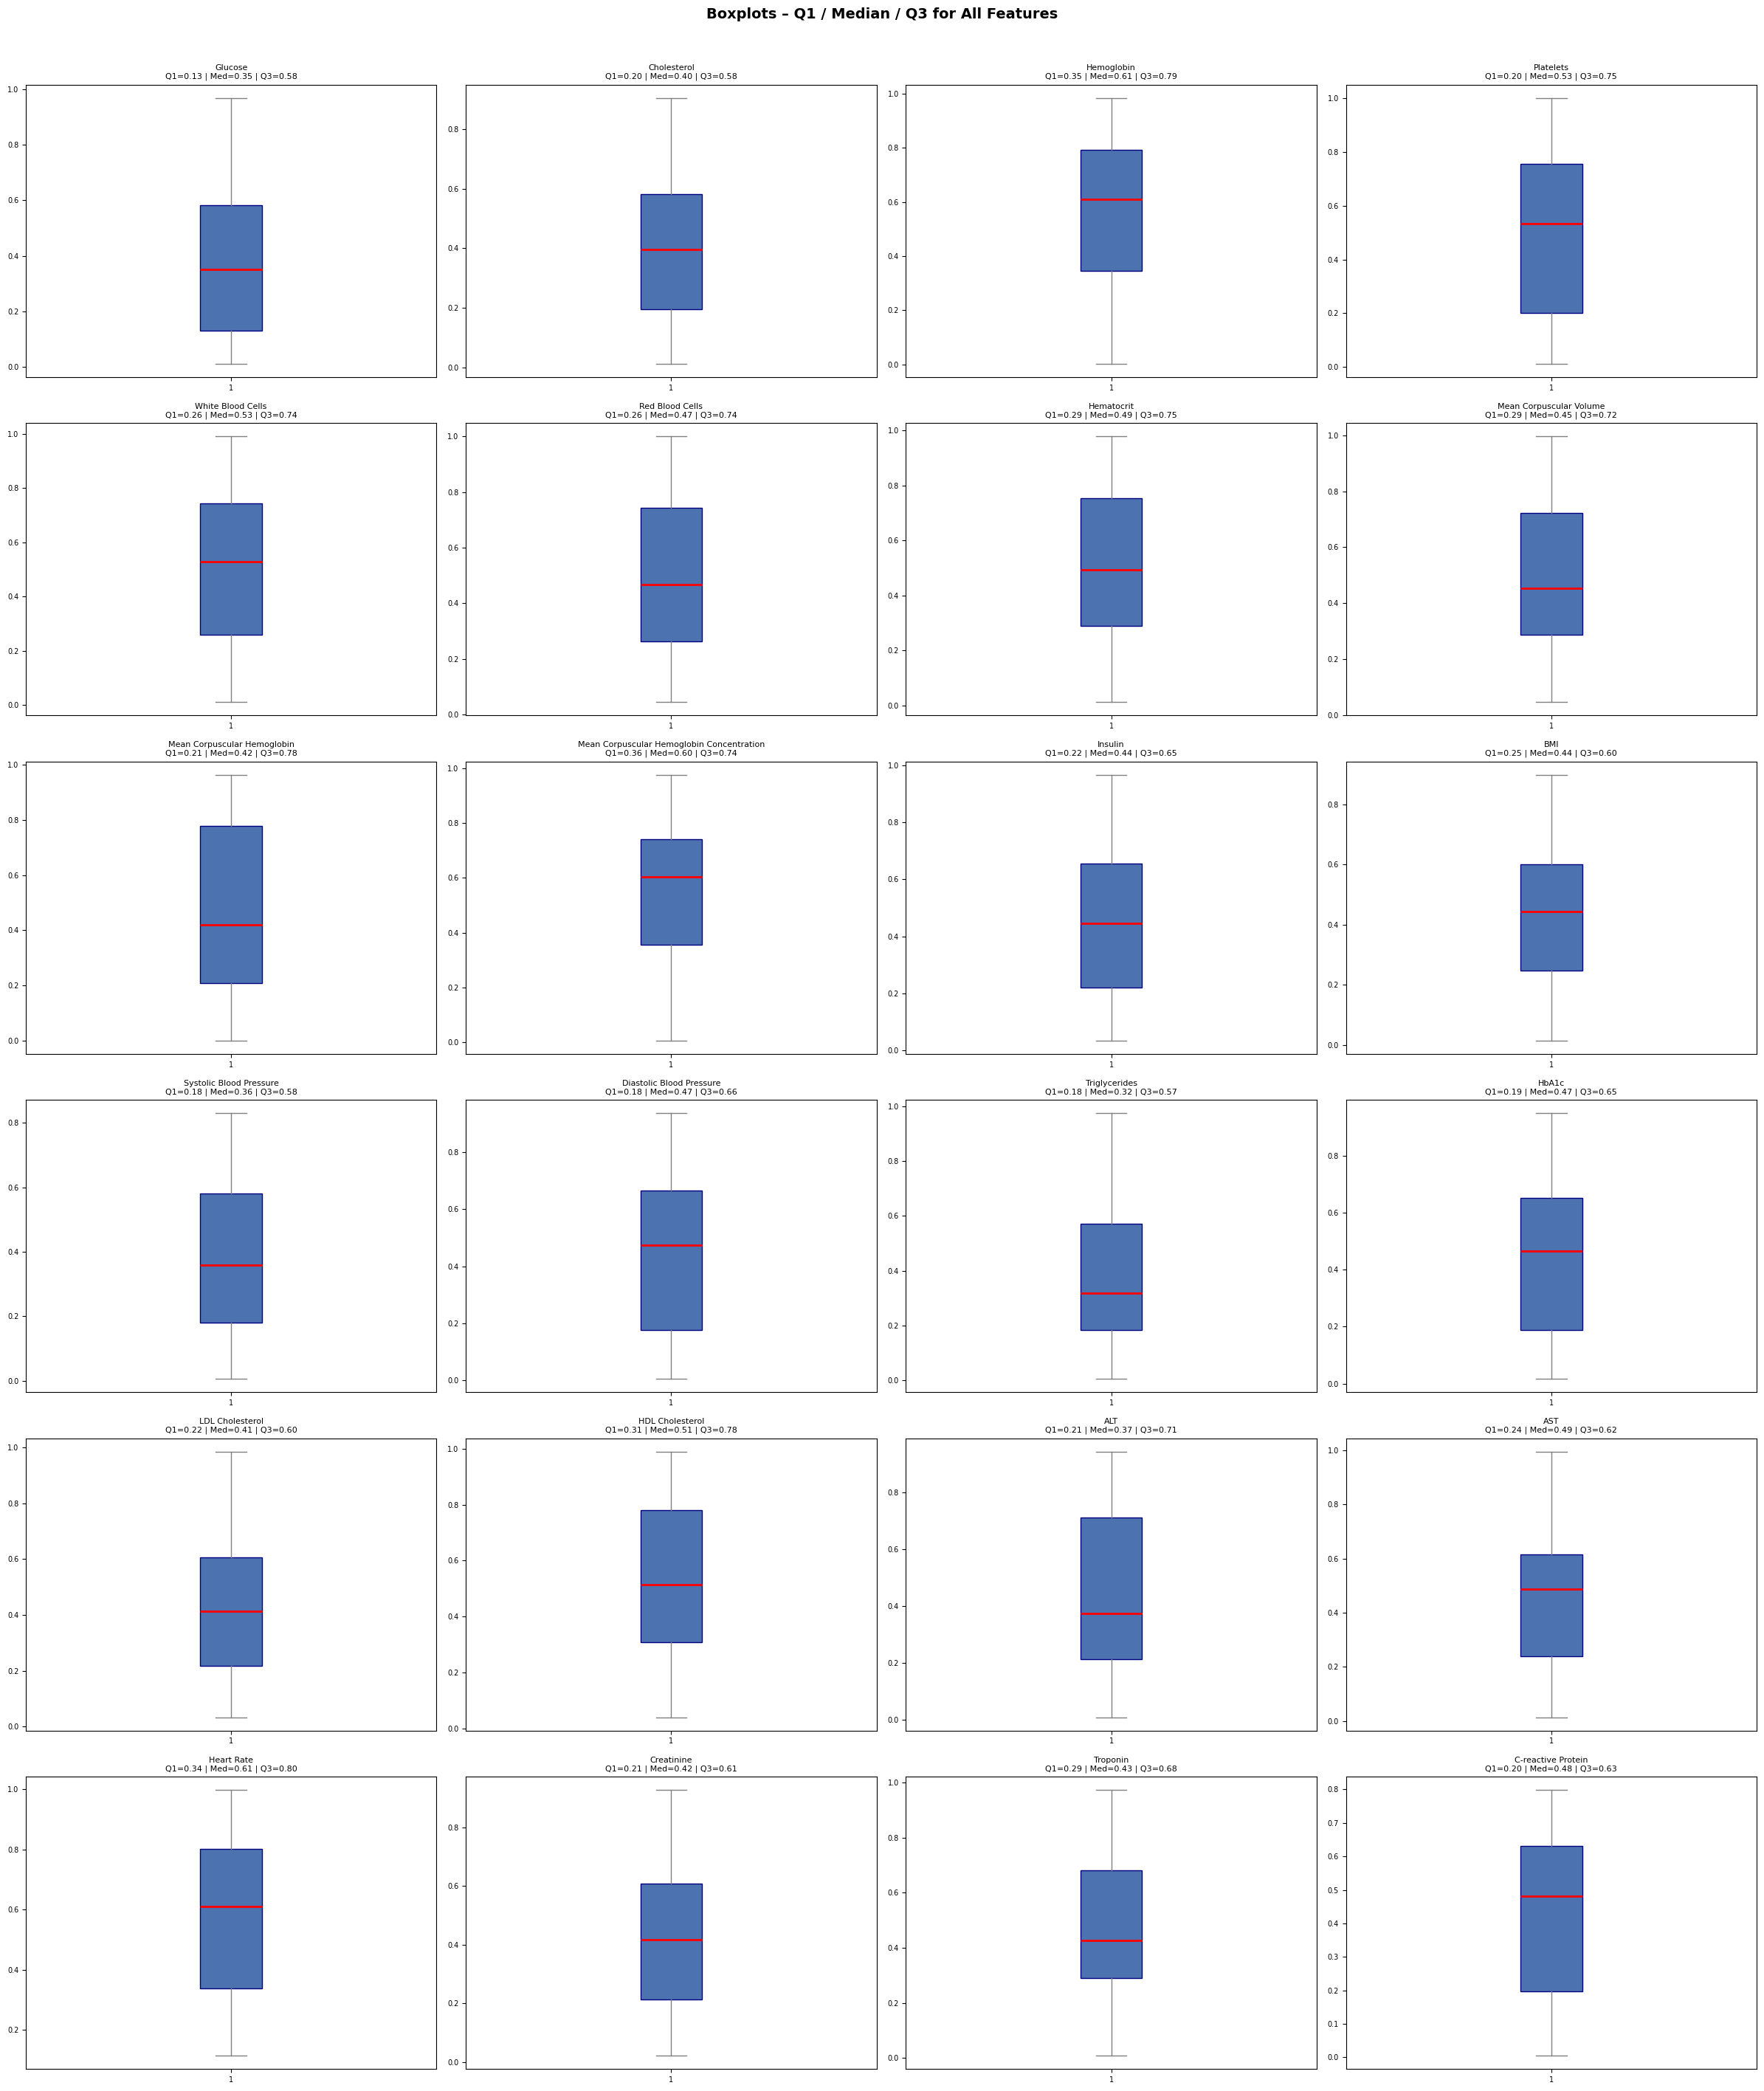

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
 
fig, axes = plt.subplots(6, 4, figsize=(24, 28))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='gray'),
                    capprops=dict(color='gray'),
                    flierprops=dict(marker='o', color='orange', alpha=0.4))
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    median = df[col].median()
    axes[i].set_title(f'{col}\nQ1={q1:.2f} | Med={median:.2f} | Q3={q3:.2f}', fontsize=8)
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots – Q1 / Median / Q3 for All Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

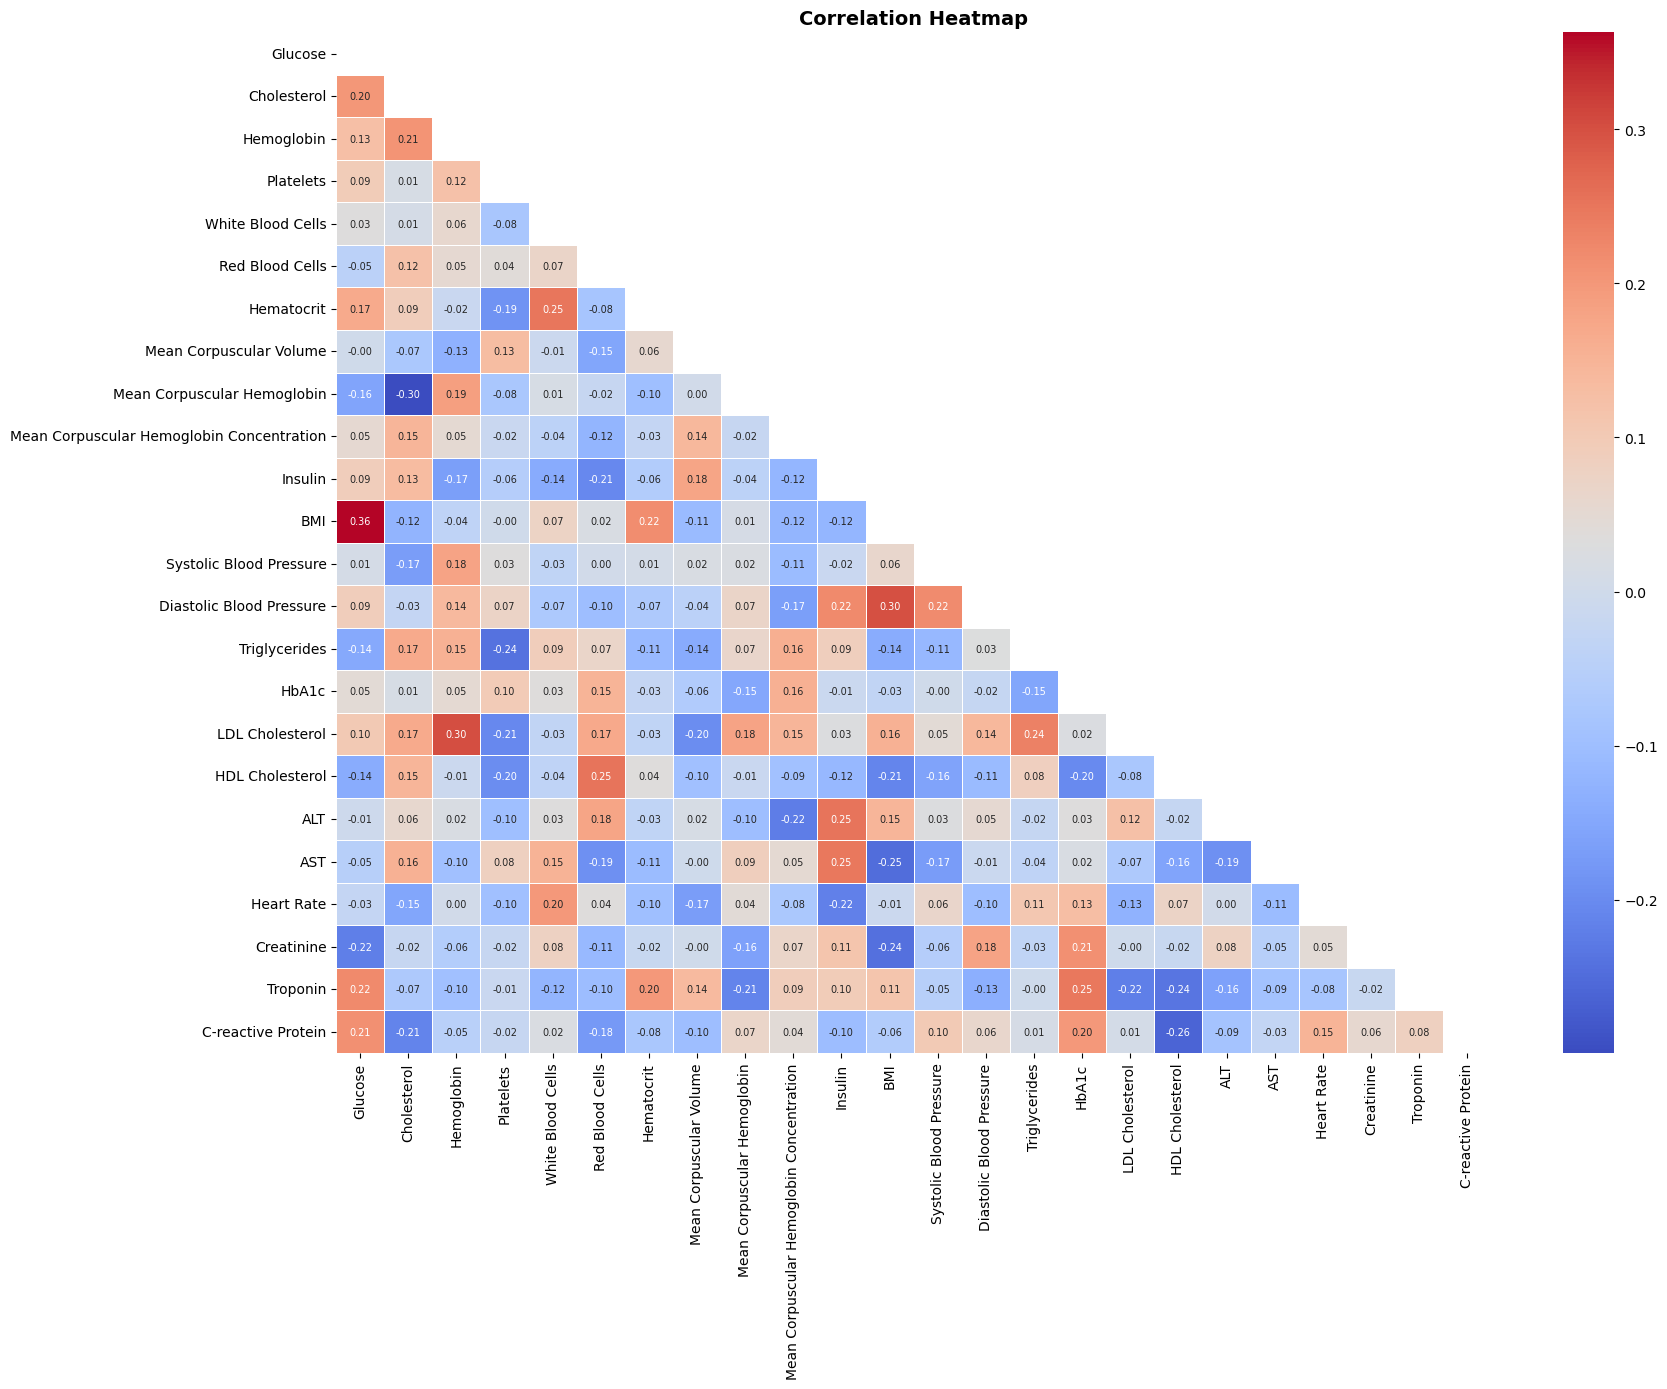

In [7]:
plt.figure(figsize=(18, 14))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

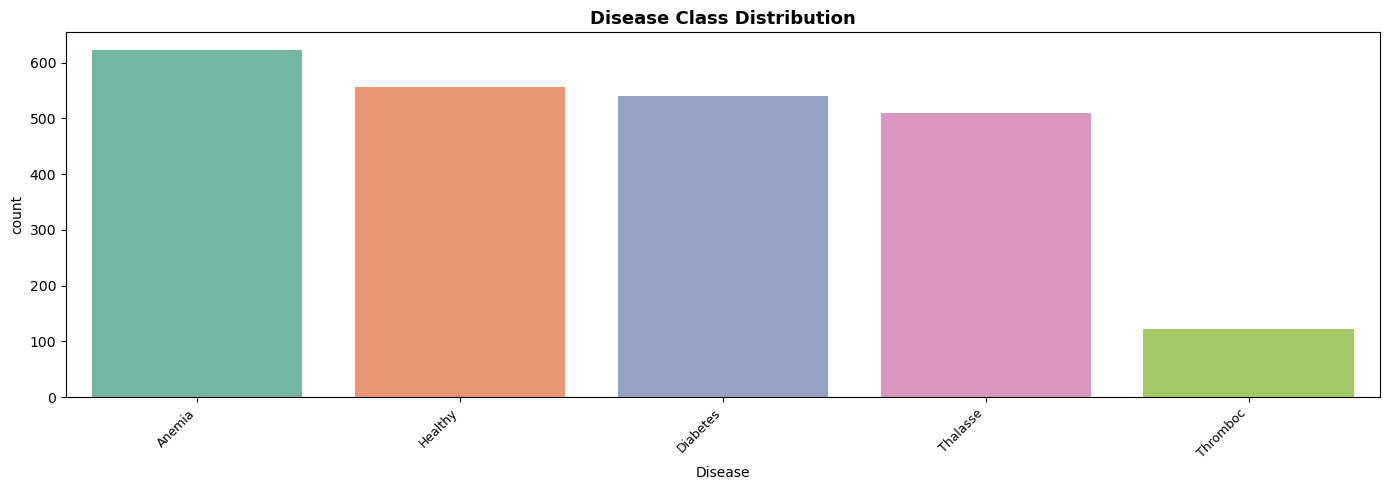

In [8]:
plt.figure(figsize=(14, 5))
order = df['Disease'].value_counts().index
sns.countplot(data=df, x='Disease', order=order, palette='Set2')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Disease Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

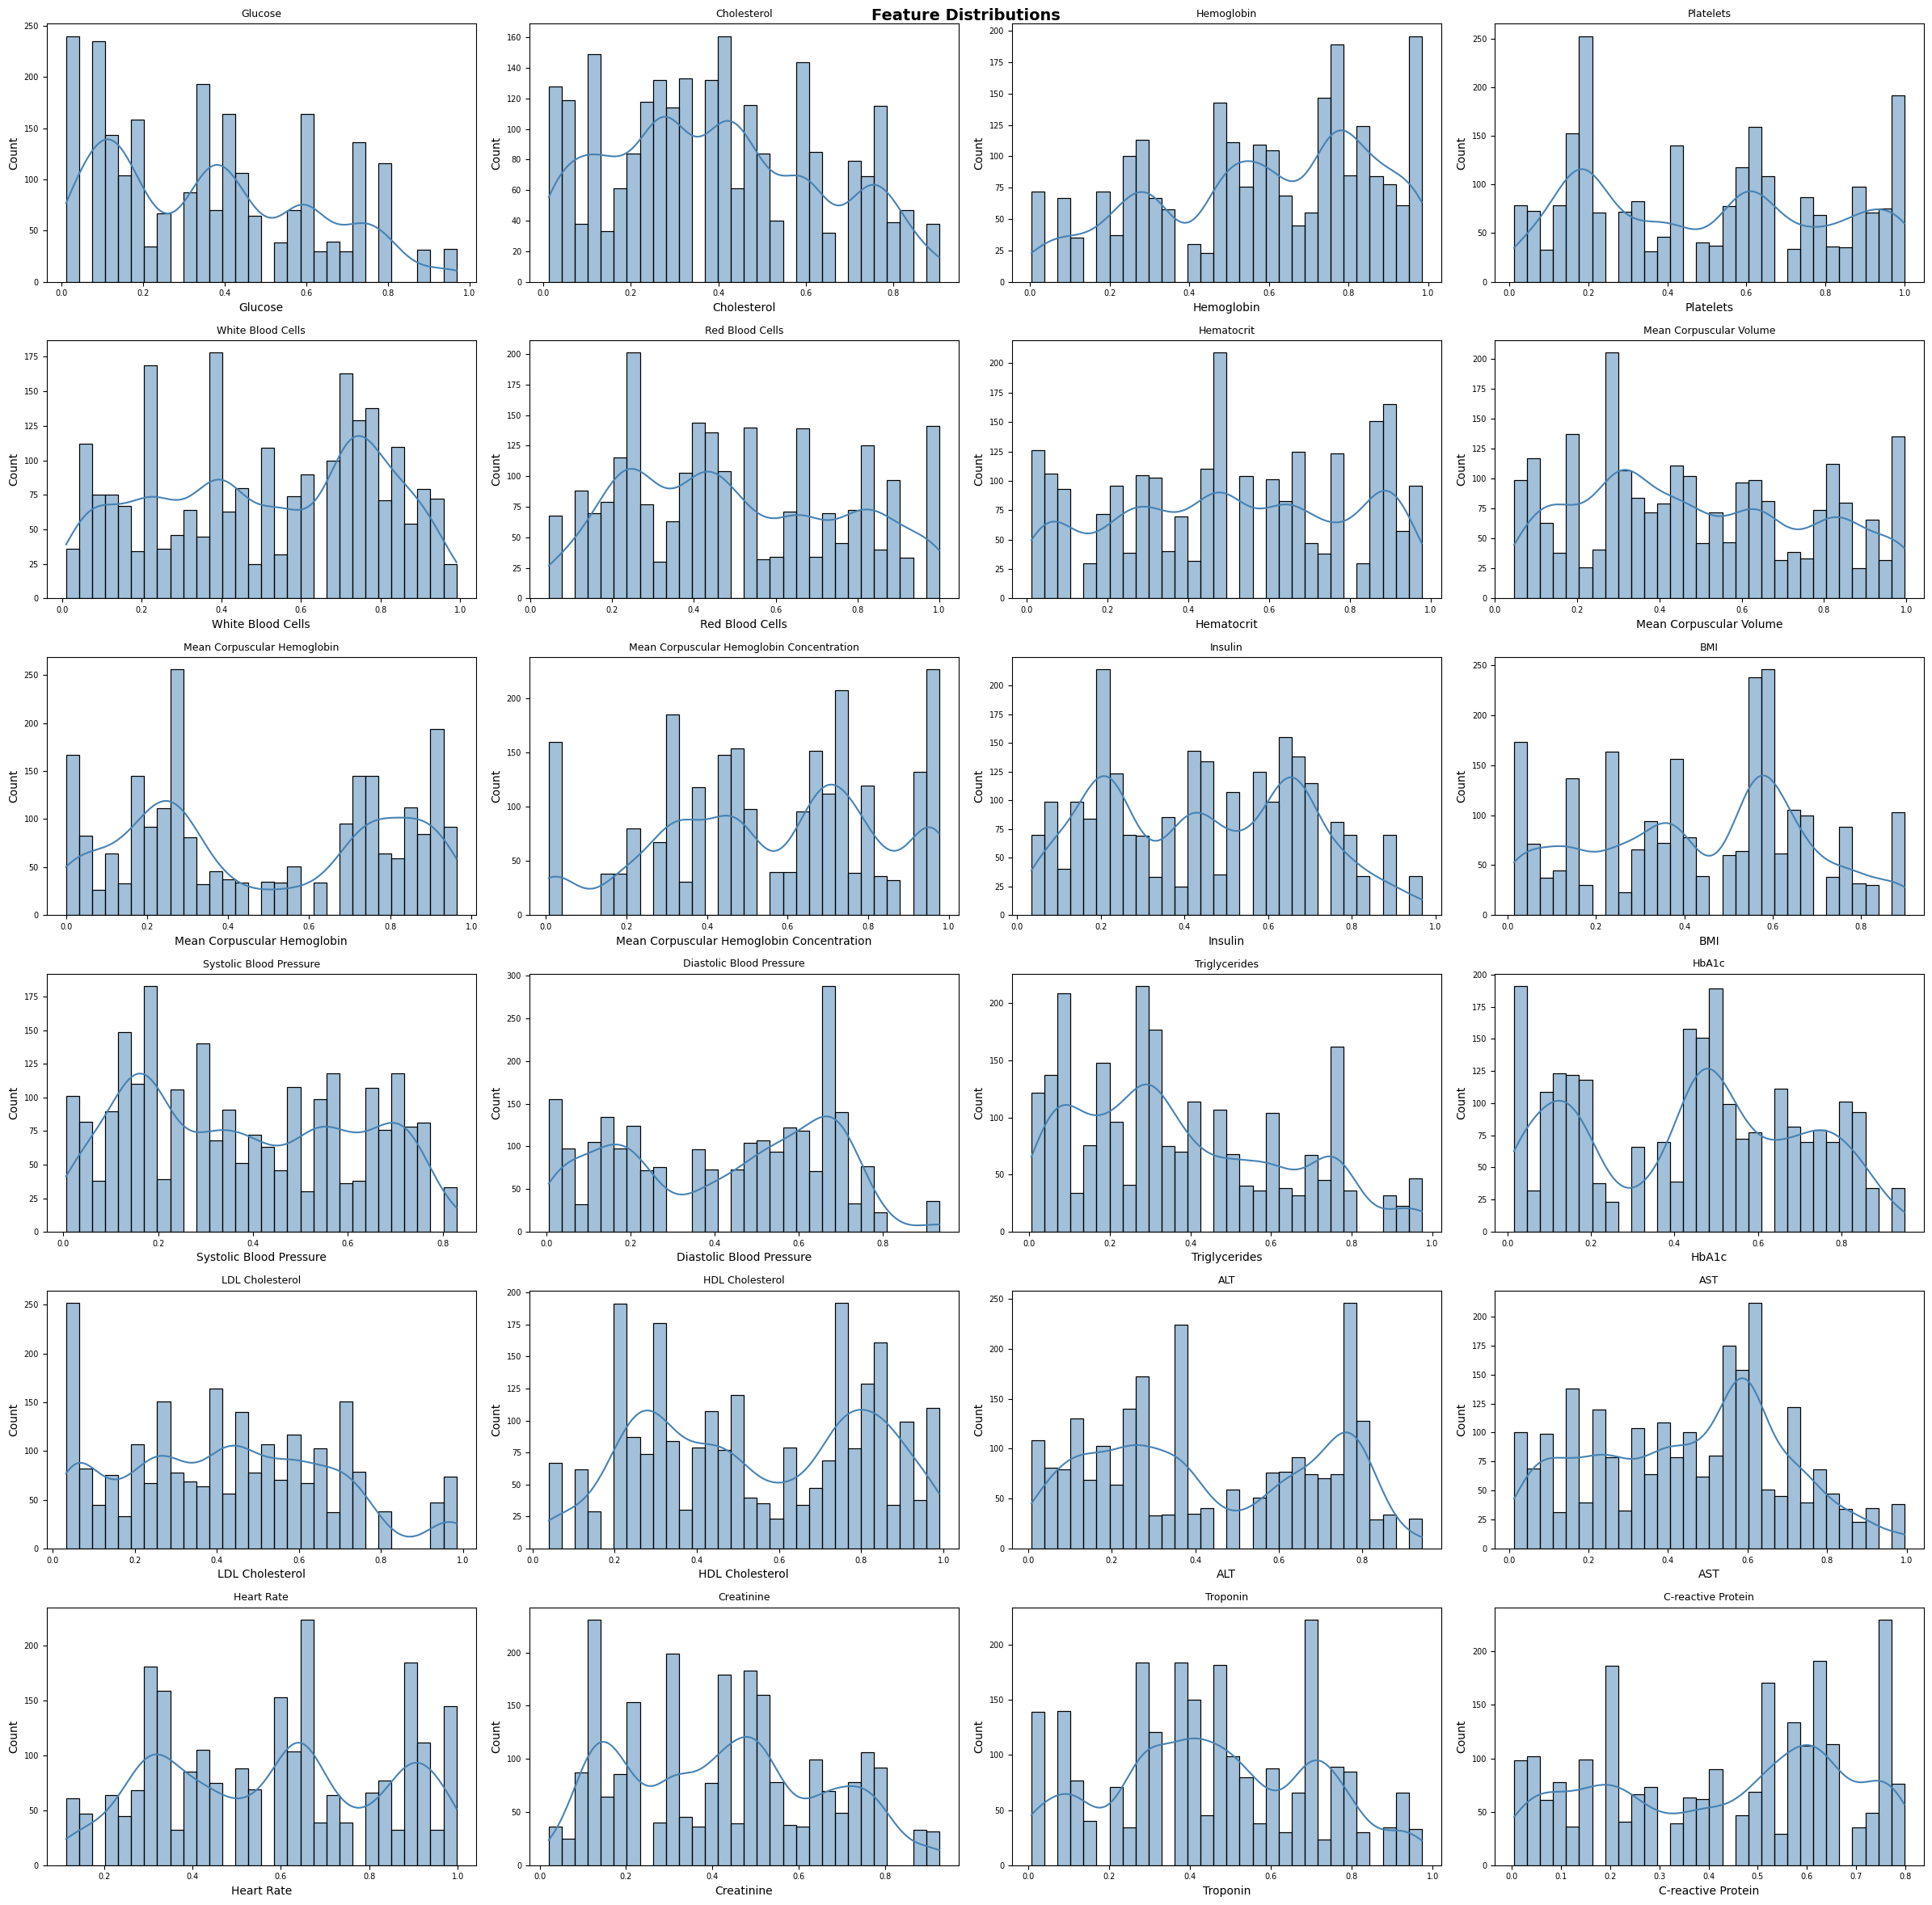

In [9]:
fig, axes = plt.subplots(6, 4, figsize=(24, 24))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
le = LabelEncoder()
df['Disease_encoded'] = le.fit_transform(df['Disease'])
 
X = df[num_cols]
y = df['Disease_encoded']
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Classes: {le.classes_}")

Train: (1880, 24) | Test: (471, 24)
Classes: ['Anemia' 'Diabetes' 'Healthy' 'Thalasse' 'Thromboc']


In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [12]:
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                     use_label_encoder=False, eval_metric='mlogloss',
                     random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [13]:
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [14]:
def get_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1 Score':  round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }
 
results = pd.DataFrame([
    get_metrics('Random Forest', y_test, rf_pred),
    get_metrics('XGBoost',       y_test, xgb_pred),
    get_metrics('SVM (RBF)',     y_test, svm_pred),
])
print(results.to_string(index=False))

        Model  Accuracy  Precision  Recall  F1 Score
Random Forest       1.0        1.0     1.0       1.0
      XGBoost       1.0        1.0     1.0       1.0
    SVM (RBF)       1.0        1.0     1.0       1.0
